# Лабораторная работа № 2.2 — Нелинейная система: итерации и Ньютон

Вариант 6. Запускай ячейки сверху вниз. Все исходные данные заданы в ноутбуке, поэтому его можно открыть отдельно от файлов input.txt и output.txt.

Решаем x₁−cos(x₂)=1, x₂−lg(x₁+1)=3. Вариант 6 задаёт параметр a=3; искомая точка — пересечение двух кривых.

## Исходные данные

Числа ниже соответствуют файлу input.txt этой работы.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import List

rows = [[0.0, 0.05], [3.0, 3.05], [1e-06]]
intervals, eps = rows[:2], rows[2][0]
a = 3.0
print('Прямоугольник:', intervals, 'ε =', eps)

Прямоугольник: [[0.0, 0.05], [3.0, 3.05]] ε = 1e-06


## Уравнения и якобиан

Матрица Якоби состоит из частных производных двух уравнений. Простая итерация переписывает систему в виде x=φ(x).

In [2]:
def f1(x1, x2):
    return x1 - math.cos(x2) - 1


def f2(x1, x2):
    return x2 - math.log10(x1 + 1) - a


def jacobian(x1, x2):
    return [[1.0, math.sin(x2)], [-1 / ((x1 + 1) * math.log(10)), 1.0]]


def phi1(x1, x2):
    return 1 + math.cos(x2)


def phi2(x1, x2):
    return a + math.log10(x1 + 1)


def residual_norm(x):
    return max(abs(f1(*x)), abs(f2(*x)))


def trig_range(function, left, right, critical_offset):
    """Exact endpoint/critical-point extrema, without sampling the interval."""
    points = [left, right]
    first = math.ceil((left-critical_offset)/math.pi)
    last = math.floor((right-critical_offset)/math.pi)
    points.extend(critical_offset + k*math.pi for k in range(first, last+1))
    values = [function(x) for x in points]
    return min(values), max(values)


def convergence_data(intervals, eps, max_iter):
    if not math.isfinite(eps) or eps <= 0:
        raise ValueError("eps must be finite and positive")
    if not isinstance(max_iter, int) or max_iter <= 0:
        raise ValueError("max_iter must be a positive integer")
    if len(intervals) != 2 or any(len(pair) != 2 for pair in intervals):
        raise ValueError("Two coordinate intervals are required")
    if any(not all(math.isfinite(x) for x in pair) or not 0 <= pair[0] < pair[1]
           for pair in intervals):
        raise ValueError("Intervals must have finite nonnegative increasing endpoints")
    (a1, b1), (a2, b2) = intervals
    sin_min, sin_max = trig_range(math.sin, a2, b2, math.pi / 2)
    cos_min, cos_max = trig_range(math.cos, a2, b2, 0)
    q = max(abs(sin_min), abs(sin_max), 1/((a1+1)*math.log(10)))
    if q >= 1:
        raise ValueError("The fixed-point map must satisfy q < 1 on the whole rectangle")
    if not (a1 <= 1+cos_min <= 1+cos_max <= b1 and
            a2 <= phi2(a1, a2) <= phi2(b1, b2) <= b2):
        raise ValueError("The fixed-point map must map the rectangle into itself")
    return q

In [3]:
q = convergence_data(intervals, eps, 1000)
print('Оценка сжатия q =', q)

Оценка сжатия q = 0.43429448190325176


## Итерации

Обе координаты в простой итерации обновляются из прежней точки. На шаге Ньютона решается JΔ=−F и прибавляется Δ.

In [4]:
def simple_iteration_method(intervals, eps, max_iter=1000, history=None):
    q = convergence_data(intervals, eps, max_iter)
    x1, x2 = [sum(pair)/2 for pair in intervals]
    for iters in range(1, max_iter + 1):
        x_next = [phi1(x1, x2), phi2(x1, x2)]
        step = max(abs(x_next[0]-x1), abs(x_next[1]-x2))
        error_bound = q / (1-q) * step
        residual = residual_norm(x_next)
        if history is not None:
            history.append(dict(iteration=iters, x=x_next, step=step,
                                error_bound=error_bound, residual=residual))
        if error_bound <= eps and residual <= eps:
            return x_next, iters
        x1, x2 = x_next
    raise RuntimeError("Simple iteration did not converge within max_iter")


def newton_method(intervals, eps, max_iter=1000, history=None):
    q = convergence_data(intervals, eps, max_iter)
    x1, x2 = [sum(pair)/2 for pair in intervals]
    for iters in range(1, max_iter + 1):
        j = jacobian(x1, x2)
        det = j[0][0]*j[1][1] - j[0][1]*j[1][0]
        if abs(det) < 1e-14:
            raise ArithmeticError("Newton Jacobian is singular")
        dx1 = (-f1(x1, x2)*j[1][1] + j[0][1]*f2(x1, x2))/det
        dx2 = (-j[0][0]*f2(x1, x2) + f1(x1, x2)*j[1][0])/det
        x_next = [x1+dx1, x2+dx2]
        if any(not math.isfinite(x) or not left <= x <= right
               for x, (left, right) in zip(x_next, intervals)):
            raise ArithmeticError("Newton iterate left the validated rectangle")
        residual = residual_norm(x_next)
        # F(x)=x-phi(x), hence ||x-x*|| <= ||F(x)||/(1-q) on the rectangle.
        error_bound = residual / (1-q)
        if history is not None:
            history.append(dict(iteration=iters, x=x_next, step=max(abs(dx1), abs(dx2)),
                                error_bound=error_bound, residual=residual))
        if error_bound <= eps and residual <= eps:
            return x_next, iters
        x1, x2 = x_next
    raise RuntimeError("Newton method did not converge within max_iter")

In [5]:
history_simple, history_newton = [], []
x_simple, n_simple = simple_iteration_method(intervals, eps, history=history_simple)
x_newton, n_newton = newton_method(intervals, eps, history=history_newton)
print('Простая итерация:', x_simple, 'шагов:', n_simple)
print('Ньютон:', x_newton, 'шагов:', n_newton)

Простая итерация: [0.00943987837908733, 3.0040805501787315] шагов: 9
Ньютон: [0.009439908634336327, 3.0040804803831773] шагов: 2


## График

График показывает результат вычисления на тех же исходных данных.

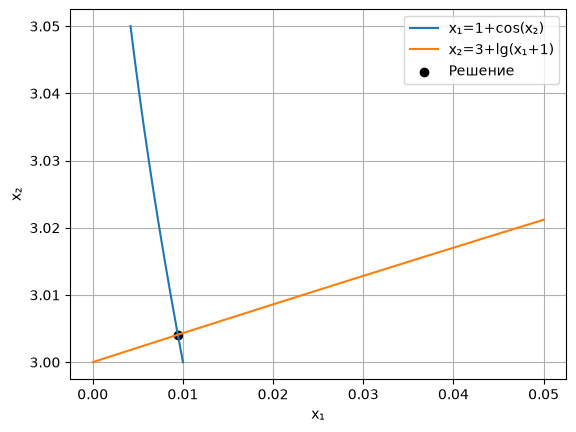

In [6]:
x1_grid = np.linspace(0, 0.05, 250)
x2_grid = np.linspace(3, 3.05, 250)
plt.plot(1+np.cos(x2_grid), x2_grid, label='x₁=1+cos(x₂)')
plt.plot(x1_grid, 3+np.log10(x1_grid+1), label='x₂=3+lg(x₁+1)')
plt.scatter(*x_newton, color='black', label='Решение')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.grid(True)
plt.legend()
plt.show()

## Самопроверка

Подставь найденную точку в обе исходные функции.

In [7]:
assert residual_norm(x_simple) <= eps and residual_norm(x_newton) <= eps
print('Невязки:', residual_norm(x_simple), residual_norm(x_newton))

Невязки: 9.244216636616898e-08 9.62980184482376e-09
